# NBT operation duration-error modelling

This notebook predicts **`duration_error_mins`**, defined as recorded operation duration minus expected duration. Positive predictions indicate a likely overrun and negative predictions indicate a likely underrun.

The workflow compares a median benchmark with five prespecified regression models: Linear Regression, Decision Tree, Random Forest, Support Vector Regression (SVR), and XGBoost. All comparisons use the same held-out test set and the same grouped cross-validation folds.

The primary analysis excludes `operation_start_hour`. A separate sensitivity analysis adds it because the start hour was reconstructed using an operational assumption that has not been confirmed by NBT. Operation end time and all outcome-derived fields are always excluded from predictors to prevent leakage.

## 1. Reproducibility and evaluation design

- The cleaned pipeline dataset is rebuilt directly, so modelling cannot silently use a stale spreadsheet.
- Identical predictor rows are assigned to the same split to prevent duplicate cases appearing in both training and evaluation data.
- Twenty percent of groups form an untouched test set. It is not used for model selection or tuning.
- The remaining data use five-fold grouped cross-validation.
- Unknown clinical values are not replaced by medians or common categories. Modelling uses a documented complete-case population.
- Scaling and one-hot encoding of observed values are fitted inside each training fold through a scikit-learn `Pipeline`.
- Mean absolute error (MAE) is the primary selection metric because it is expressed in minutes and is less dominated by unusually large errors than RMSE.
- RMSE and R-squared are reported as complementary measures. Lower MAE/RMSE and higher R-squared are better.
- The two strongest non-benchmark models by cross-validated MAE receive a compact, prespecified grid search. This avoids selecting hyperparameters from the test set.

In [13]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    GroupShuffleSplit,
    cross_validate,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from nbt_pipeline.modeling import (
    OUTCOME_OR_LEAKAGE_COLUMNS,
    RANDOM_STATE,
    TARGET_COLUMN,
    build_model_pipeline,
    get_regression_models,
    make_predictor_sets,
    predictor_row_groups,
)
from nbt_pipeline.preprocessing import build_analysis_dataset

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
N_SPLITS = 5
TEST_SIZE = 0.20

## 2. Build and audit the cleaned data

The analysis dataset is created by the reusable cleaning pipeline. Seven exact source-level duplicate records are removed before analytical columns are discarded. Rows that share the same final predictor profile are still assigned to the same split so repeated analytical profiles cannot leak across evaluation boundaries.

Rows without an observed regression target are ineligible for supervised learning. In line with the agreed conservative treatment of clinical missingness, rows missing any selected predictor are also excluded rather than filled with assumed values. The complete-case count and exclusions are reported explicitly.

In [14]:
analysis_df = build_analysis_dataset()
target_missing_n = int(analysis_df[TARGET_COLUMN].isna().sum())
target_nonfinite_n = int((
    analysis_df[TARGET_COLUMN].notna()
    & ~np.isfinite(analysis_df[TARGET_COLUMN])
).sum())
raw_primary_X, raw_sensitivity_X, raw_y = make_predictor_sets(analysis_df)
complete_case_mask = raw_sensitivity_X.notna().all(axis=1)
primary_X = raw_primary_X.loc[complete_case_mask].copy()
sensitivity_X = raw_sensitivity_X.loc[complete_case_mask].copy()
y = raw_y.loc[complete_case_mask].copy()
review_flag = (
    analysis_df.loc[y.index, "duration_timing_review_flag"]
    .fillna(False)
    .astype(bool)
)

data_audit = pd.DataFrame({
    "check": [
        "analysis rows",
        "analysis columns",
        "identical final analysis profiles retained",
        "missing target values",
        "non-finite target values",
        "rows eligible for regression",
        "rows excluded for incomplete predictors",
        "complete-case modelling rows",
        "duration-review records in complete cases",
        "primary predictor columns",
        "sensitivity predictor columns",
        "outcome/leakage columns in primary predictors",
        "operation_start_hour in primary predictors",
        "operation_start_hour in sensitivity predictors",
    ],
    "value": [
        len(analysis_df),
        analysis_df.shape[1],
        int(analysis_df.duplicated().sum()),
        target_missing_n,
        target_nonfinite_n,
        len(raw_y),
        int((~complete_case_mask).sum()),
        len(y),
        int(review_flag.sum()),
        primary_X.shape[1],
        sensitivity_X.shape[1],
        len(set(OUTCOME_OR_LEAKAGE_COLUMNS).intersection(primary_X.columns)),
        "operation_start_hour" in primary_X.columns,
        "operation_start_hour" in sensitivity_X.columns,
    ],
})
data_audit

,check,value
0,analysis rows,14918
1,analysis columns,22
2,identical final analysis profiles retained,11
3,missing target values,355
4,non-finite target values,0
5,rows eligible for regression,14563
6,rows excluded for incomplete predictors,9325
7,complete-case modelling rows,5238
8,duration-review records in complete cases,1
9,primary predictor columns,12


In [15]:
assert analysis_df.shape == (14911, 22)
assert y.notna().all() and np.isfinite(y).all()
assert primary_X.notna().sum().sum() == primary_X.size
assert sensitivity_X.notna().sum().sum() == sensitivity_X.size
assert not set(OUTCOME_OR_LEAKAGE_COLUMNS).intersection(primary_X.columns)
assert "operation_start_hour" not in primary_X.columns
assert "operation_start_hour" in sensitivity_X.columns
assert "operation_end_time" not in sensitivity_X.columns
assert "operation_end_time_inferred" not in sensitivity_X.columns

column_roles = pd.DataFrame({
    "column": analysis_df.columns,
    "role": [
        "regression target" if c == TARGET_COLUMN
        else "outcome/reporting only" if c in OUTCOME_OR_LEAKAGE_COLUMNS
        else "sensitivity predictor only" if c == "operation_start_hour"
        else "primary predictor"
        for c in analysis_df.columns
    ],
    "missing_n": [int(analysis_df[c].isna().sum()) for c in analysis_df.columns],
    "unique_n": [int(analysis_df[c].nunique(dropna=True)) for c in analysis_df.columns],
})
column_roles

AssertionError: 

## 3. Grouped training, cross-validation and test partitions

Rows with identical primary predictors receive the same group hash. Group splitting is stricter than ordinary random splitting for this dataset because it prevents identical cases from appearing on both sides of an evaluation boundary. The same partitions are reused for every model and for the start-hour sensitivity comparison.

In [ ]:
groups = predictor_row_groups(primary_X)
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(primary_X, y, groups=groups))

X_train_primary = primary_X.iloc[train_idx].copy()
X_test_primary = primary_X.iloc[test_idx].copy()
X_train_sensitivity = sensitivity_X.iloc[train_idx].copy()
X_test_sensitivity = sensitivity_X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()
review_train = review_flag.iloc[train_idx].copy()
review_test = review_flag.iloc[test_idx].copy()

assert set(groups_train).isdisjoint(set(groups_test))

group_cv = GroupKFold(n_splits=N_SPLITS)
cv_splits = list(group_cv.split(X_train_primary, y_train, groups=groups_train))

split_audit = pd.DataFrame({
    "partition": ["training", "untouched test"],
    "rows": [len(train_idx), len(test_idx)],
    "unique predictor groups": [groups_train.nunique(), groups_test.nunique()],
    "target mean": [y_train.mean(), y_test.mean()],
    "target median": [y_train.median(), y_test.median()],
    "target standard deviation": [y_train.std(), y_test.std()],
})
split_audit

,partition,rows,unique predictor groups,target mean,target median,target standard deviation
0,training,4197,3973,-23.408863,-25.0,49.815102
1,untouched test,1041,994,-26.219981,-25.0,66.589562


## 4. Fair benchmark and five-model comparison

The dummy median model establishes the minimum useful benchmark. Each candidate receives identical rows and folds. Reported values are the mean and standard deviation across the five validation folds; the untouched test data remain unused.

In [ ]:
SCORING = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

models = get_regression_models()
comparison_rows = []

for model_name, model in models.items():
    started = time.perf_counter()
    scores = cross_validate(
        build_model_pipeline(model),
        X_train_primary,
        y_train,
        cv=cv_splits,
        scoring=SCORING,
        n_jobs=1,
        error_score="raise",
    )
    comparison_rows.append({
        "model": model_name,
        "CV MAE mean": -scores["test_MAE"].mean(),
        "CV MAE SD": scores["test_MAE"].std(ddof=1),
        "CV RMSE mean": -scores["test_RMSE"].mean(),
        "CV RMSE SD": scores["test_RMSE"].std(ddof=1),
        "CV R2 mean": scores["test_R2"].mean(),
        "CV R2 SD": scores["test_R2"].std(ddof=1),
        "runtime seconds": time.perf_counter() - started,
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("CV MAE mean", ignore_index=True)
)
model_comparison

,model,CV MAE mean,CV MAE SD,CV RMSE mean,CV RMSE SD,CV R2 mean,CV R2 SD,runtime seconds
0,XGBoost,26.813751,0.963294,42.522145,1.746807,0.261868,0.076484,3.899507
1,Random forest,26.952022,1.138243,42.760852,2.066289,0.254577,0.068601,62.877266
2,SVR,27.132346,1.831540,44.783695,4.014187,0.188555,0.027838,6.667779
3,Linear regression,28.314392,0.767449,43.390447,1.366442,0.229183,0.099394,0.527255
4,Decision tree,28.651077,1.298869,45.448634,2.789801,0.158208,0.086365,0.413368
5,Dummy median benchmark,32.550444,1.949795,49.715458,3.867169,-0.001077,0.000447,0.258901


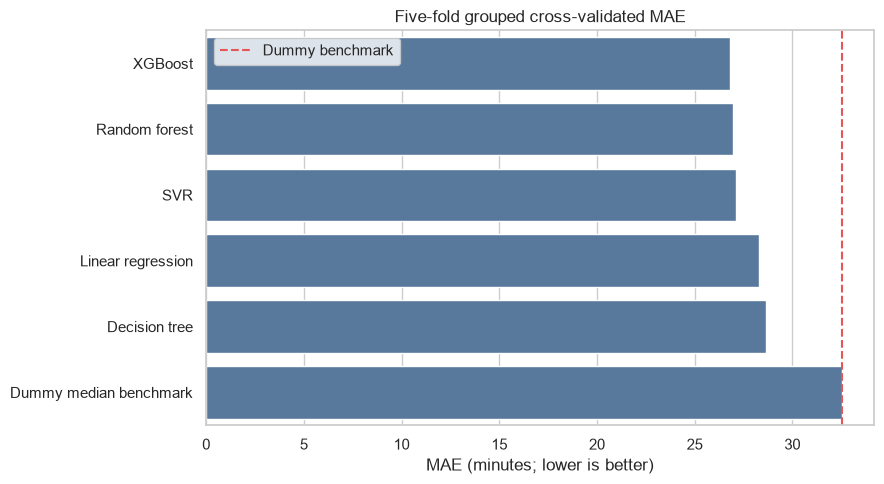

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=model_comparison, x="CV MAE mean", y="model", ax=ax, color="#4C78A8")
ax.axvline(
    model_comparison.loc[model_comparison["model"].eq("Dummy median benchmark"), "CV MAE mean"].iloc[0],
    color="#E45756", linestyle="--", label="Dummy benchmark"
)
ax.set(title="Five-fold grouped cross-validated MAE", xlabel="MAE (minutes; lower is better)", ylabel="")
ax.legend()
plt.tight_layout()

## 5. Hyperparameter tuning on training folds only

The two best non-benchmark models advance to a compact grid search. The grids are intentionally small and prespecified to reduce overfitting to cross-validation results. The selection criterion remains MAE.

In [ ]:
PARAMETER_GRIDS = {
    "Linear regression": {"model__fit_intercept": [True, False]},
    "Decision tree": {
        "model__max_depth": [6, 12],
        "model__min_samples_leaf": [5, 20],
    },
    "Random forest": {
        "model__max_depth": [12, None],
        "model__min_samples_leaf": [2, 5],
    },
    "SVR": {
        "model__C": [1.0, 10.0],
        "model__epsilon": [0.1, 5.0],
    },
    "XGBoost": {
        "model__max_depth": [3, 6],
        "model__learning_rate": [0.03, 0.08],
    },
}

candidate_names = (
    model_comparison.loc[~model_comparison["model"].eq("Dummy median benchmark"), "model"]
    .head(2)
    .tolist()
)
tuned_searches = {}
tuning_rows = []

for model_name in candidate_names:
    search = GridSearchCV(
        estimator=build_model_pipeline(models[model_name]),
        param_grid=PARAMETER_GRIDS[model_name],
        scoring=SCORING,
        refit="MAE",
        cv=cv_splits,
        n_jobs=1,
        error_score="raise",
        return_train_score=False,
    )
    started = time.perf_counter()
    search.fit(X_train_primary, y_train)
    tuned_searches[model_name] = search
    best_index = search.best_index_
    tuning_rows.append({
        "model": model_name,
        "best parameters": search.best_params_,
        "tuned CV MAE": -search.cv_results_["mean_test_MAE"][best_index],
        "tuned CV RMSE": -search.cv_results_["mean_test_RMSE"][best_index],
        "tuned CV R2": search.cv_results_["mean_test_R2"][best_index],
        "runtime seconds": time.perf_counter() - started,
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("tuned CV MAE", ignore_index=True)
tuning_results

,model,best parameters,tuned CV MAE,tuned CV RMSE,tuned CV R2,runtime seconds
0,XGBoost,"{'model__learning_rate': 0.03, 'model__max_dep...",26.847754,42.331567,0.269409,10.776182
1,Random forest,"{'model__max_depth': 12, 'model__min_samples_l...",27.088311,42.917947,0.249642,306.462146


## 6. Final evaluation on the untouched test set

Only the tuned model with the lowest training cross-validated MAE is selected. The test set is then evaluated once. The dummy benchmark is also evaluated on exactly the same test rows for context.

In [ ]:
best_model_name = tuning_results.iloc[0]["model"]
best_primary_model = tuned_searches[best_model_name].best_estimator_

dummy_model = build_model_pipeline(models["Dummy median benchmark"])
dummy_model.fit(X_train_primary, y_train)
dummy_prediction = dummy_model.predict(X_test_primary)

primary_prediction = best_primary_model.predict(X_test_primary)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

test_results = pd.DataFrame([
    {"model": "Dummy median benchmark", **regression_metrics(y_test, dummy_prediction)},
    {"model": f"Tuned {best_model_name}", **regression_metrics(y_test, primary_prediction)},
])
test_results

,model,MAE,RMSE,R2
0,Dummy median benchmark,35.390970,66.568751,-0.000336
1,Tuned XGBoost,28.779712,58.140564,0.236931


## 7. Start-hour sensitivity analysis

The winning primary-model specification is refitted with `operation_start_hour` added. Primary and sensitivity versions use identical folds, hyperparameters and test rows. This isolates the incremental value of the provisional reconstructed start hour. The version without start hour remains the primary result regardless of whether the sensitivity metric improves.

In [ ]:
sensitivity_model = clone(best_primary_model)
sensitivity_cv = cross_validate(
    sensitivity_model,
    X_train_sensitivity,
    y_train,
    cv=cv_splits,
    scoring=SCORING,
    n_jobs=1,
    error_score="raise",
)
sensitivity_model.fit(X_train_sensitivity, y_train)
sensitivity_prediction = sensitivity_model.predict(X_test_sensitivity)

primary_cv_row = tuning_results.loc[tuning_results["model"].eq(best_model_name)].iloc[0]
sensitivity_comparison = pd.DataFrame([
    {
        "feature set": "Primary: start hour excluded",
        "CV MAE": primary_cv_row["tuned CV MAE"],
        "CV RMSE": primary_cv_row["tuned CV RMSE"],
        "CV R2": primary_cv_row["tuned CV R2"],
        **{f"test {k}": v for k, v in regression_metrics(y_test, primary_prediction).items()},
    },
    {
        "feature set": "Sensitivity: start hour included",
        "CV MAE": -sensitivity_cv["test_MAE"].mean(),
        "CV RMSE": -sensitivity_cv["test_RMSE"].mean(),
        "CV R2": sensitivity_cv["test_R2"].mean(),
        **{f"test {k}": v for k, v in regression_metrics(y_test, sensitivity_prediction).items()},
    },
])
sensitivity_comparison

,feature set,CV MAE,CV RMSE,CV R2,test MAE,test RMSE,test R2
0,Primary: start hour excluded,26.847754,42.331567,0.269409,28.779712,58.140564,0.236931
1,Sensitivity: start hour included,26.578606,41.785262,0.288229,28.559458,57.525911,0.252980


## 8. Duration-review-record sensitivity analysis

The 12 flagged duration records are retained in the cleaned audit dataset because the flag does not prove that they are wrong. A sensitivity model removes flagged records from both model fitting and evaluation, using the same tuned specification. This shows whether the conclusion depends materially on those questionable durations.

In [ ]:
keep_train = ~review_train.to_numpy()
keep_test = ~review_test.to_numpy()
X_train_unflagged = X_train_primary.iloc[keep_train].copy()
y_train_unflagged = y_train.iloc[keep_train].copy()
groups_train_unflagged = groups_train.iloc[keep_train].copy()
X_test_unflagged = X_test_primary.iloc[keep_test].copy()
y_test_unflagged = y_test.iloc[keep_test].copy()

unflagged_cv = list(GroupKFold(n_splits=N_SPLITS).split(
    X_train_unflagged, y_train_unflagged, groups=groups_train_unflagged
))
unflagged_model = clone(best_primary_model)
unflagged_cv_scores = cross_validate(
    unflagged_model,
    X_train_unflagged,
    y_train_unflagged,
    cv=unflagged_cv,
    scoring=SCORING,
    n_jobs=1,
    error_score="raise",
)
unflagged_model.fit(X_train_unflagged, y_train_unflagged)
unflagged_prediction = unflagged_model.predict(X_test_unflagged)

duration_review_sensitivity = pd.DataFrame([
    {
        "analysis": "Primary: flagged records retained",
        "training rows": len(y_train),
        "test rows": len(y_test),
        "CV MAE": primary_cv_row["tuned CV MAE"],
        **{f"test {k}": v for k, v in regression_metrics(y_test, primary_prediction).items()},
    },
    {
        "analysis": "Sensitivity: flagged records excluded",
        "training rows": len(y_train_unflagged),
        "test rows": len(y_test_unflagged),
        "CV MAE": -unflagged_cv_scores["test_MAE"].mean(),
        **{f"test {k}": v for k, v in regression_metrics(y_test_unflagged, unflagged_prediction).items()},
    },
])
duration_review_sensitivity

,analysis,training rows,test rows,CV MAE,test MAE,test RMSE,test R2
0,Primary: flagged records retained,4197,1041,26.847754,28.779712,58.140564,0.236931
1,Sensitivity: flagged records excluded,4196,1041,26.875366,28.713505,57.985423,0.240998


## 9. Prediction and residual diagnostics

Residual plots help reveal systematic underprediction, overprediction and changing error spread. They do not replace external validation or operational review.

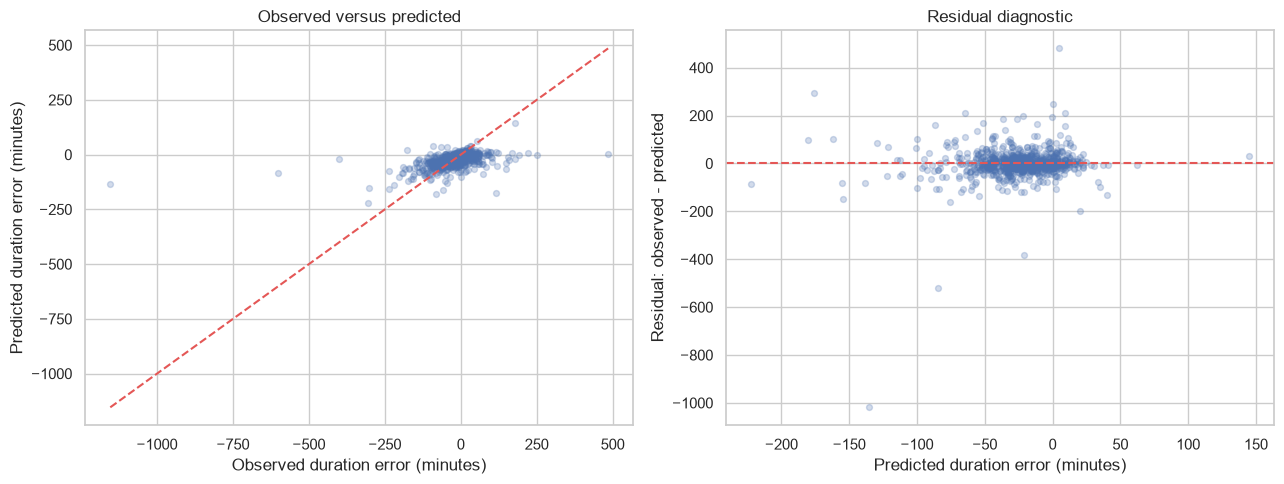

In [ ]:
residuals = y_test.to_numpy() - primary_prediction
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, primary_prediction, alpha=0.25, s=18)
limits = [min(y_test.min(), primary_prediction.min()), max(y_test.max(), primary_prediction.max())]
axes[0].plot(limits, limits, linestyle="--", color="#E45756")
axes[0].set(xlabel="Observed duration error (minutes)", ylabel="Predicted duration error (minutes)", title="Observed versus predicted")

axes[1].scatter(primary_prediction, residuals, alpha=0.25, s=18)
axes[1].axhline(0, linestyle="--", color="#E45756")
axes[1].set(xlabel="Predicted duration error (minutes)", ylabel="Residual: observed - predicted", title="Residual diagnostic")
plt.tight_layout()

In [ ]:
residual_summary = pd.DataFrame({
    "measure": ["mean residual", "median residual", "residual SD", "absolute error 90th percentile"],
    "value": [
        residuals.mean(),
        np.median(residuals),
        residuals.std(ddof=1),
        np.quantile(np.abs(residuals), 0.90),
    ],
})
residual_summary

,measure,value
0,mean residual,-0.751067
1,median residual,-2.703729
2,residual SD,58.163656
3,absolute error 90th percentile,66.551899


## 10. Save reproducible results

The comparison tables and test predictions are exported separately from the source data. Predictions contain the original dataframe index only—not patient, staff or free-text identifiers.

In [ ]:
RESULT_DIR = PROJECT_ROOT / "result" / "regression"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

model_comparison.to_csv(RESULT_DIR / "cross_validation_model_comparison.csv", index=False)
tuning_results.assign(**{"best parameters": tuning_results["best parameters"].astype(str)}).to_csv(
    RESULT_DIR / "hyperparameter_tuning_results.csv", index=False
)
test_results.to_csv(RESULT_DIR / "untouched_test_results.csv", index=False)
sensitivity_comparison.to_csv(RESULT_DIR / "start_hour_sensitivity.csv", index=False)
duration_review_sensitivity.to_csv(RESULT_DIR / "duration_review_sensitivity.csv", index=False)
pd.DataFrame({
    "source_index": y_test.index,
    "observed_duration_error_mins": y_test.to_numpy(),
    "primary_prediction": primary_prediction,
    "primary_residual": residuals,
    "start_hour_sensitivity_prediction": sensitivity_prediction,
}).to_csv(RESULT_DIR / "test_predictions.csv", index=False)

pd.DataFrame({
    "result": ["selected model", "training rows", "test rows", "primary predictors", "sensitivity predictors"],
    "value": [best_model_name, len(y_train), len(y_test), primary_X.shape[1], sensitivity_X.shape[1]],
})

,result,value
0,selected model,XGBoost
1,training rows,4197
2,test rows,1041
3,primary predictors,12
4,sensitivity predictors,13


## 11. Interpretation boundaries and next decisions

- The selected model is the strongest of the tested specifications on internal grouped cross-validation; it is not automatically ready for deployment.
- No unknown clinical value is replaced with a guessed median or common category; results apply to the reported complete-case population.
- Test performance should be interpreted against the dummy benchmark and in minutes, not from R-squared alone.
- `operation_start_hour` remains sensitivity-only because its reconstruction is provisional.
- End times, recorded duration, duration status, overrun flags, tolerance fields and duration-review flags were excluded from predictors.
- The next validation step is temporal or external validation on a later NBT dataset, followed by calibration and operational-impact assessment.
- A separate classification notebook can later address the different question of predicting `meaningful_overrun_flag`. It must not reuse post-operation outcome fields as predictors.